# Homework 5: Model Selection and Extreme Values

BEE 4850/5850, Spring 2025

**Name**: Ali Shabazz

**ID**: aas348

> **Due Date**
>
> Friday, 5/2/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practicing approaches to
extreme value analysis and using information criteria to assess evidence
for models.

-   Problem 1 asks you to compare stationary and non-stationary block
    maxima models for daily maximum temperature data.
-   Problem 2 asks you to use peaks-over-thresholds modeling on the same
    dataset from Problem 1.
-   Problem 3 (only required for students in BEE 5850) asks you to
    compare several linear regression models for environmental
    influences on non-accidental death data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\aliap\Cornell\BEE 5850\hw05-AAPShabazz`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Dates
using Optim

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Let’s look at how (modeled) annual maximum temperatures have (or have
not) increased in Ithaca from 1850–2014. Model output from NOAA’s
GFDL-ESM4 climate model (one of the models used in the latest Climate
Model Intercomparison Project,
[CMIP6](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fcds.climate.copernicus.eu%2Fcdsapp%23%21%2Fdataset%2Fprojections-cmip6%3Ftab%3Doverview))
is available in `data/gfdl-esm4-tempmax-ithaca.csv`. While this model
output has not been bias-corrected, we won’t worry about that for the
purposes of this assignment. The temperature data is in degrees Celsius,
and the dates are provided as calendar dates.

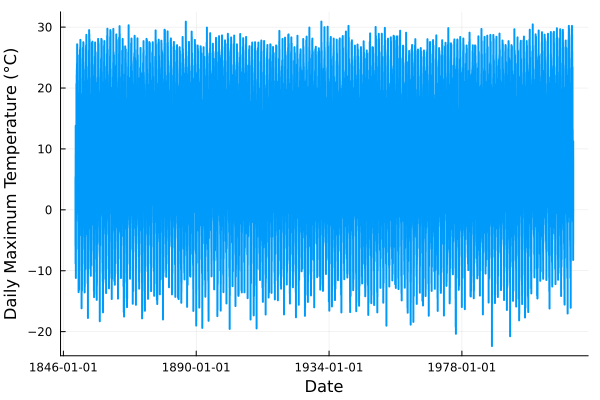

In [3]:
ithaca_dat = CSV.read("data/gfdl-esm4-tempmax-ithaca.csv", DataFrame)
plot(ithaca_dat.Day, ithaca_dat.TempMax, lw=2, xlabel="Date", ylabel="Daily Maximum Temperature (°C)", legend=false)

**In this problem**:

-   Load the (daily maximum) temperature data from
    `data/gfdl-esm4-tempmax-ithaca.csv`. Find the modeled annual maximum
    temperatures and plot them.
-   Fit a stationary GEV model to the annual maximum series and report
    your parameter estimates. Plot the fitted distribution along with
    the data. What type of GEV distribution did you end up with? What is
    the 100-year return level?
-   Now fit a nonstationary GEV with respect to time (only the location
    parameter should be non-stationary),
    $y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling
    purposes, begin with $t=0$ corresponding to 1850).
-   What are the AIC values for each model? What can you conclude about
    the relative evidence for non-stationarity?


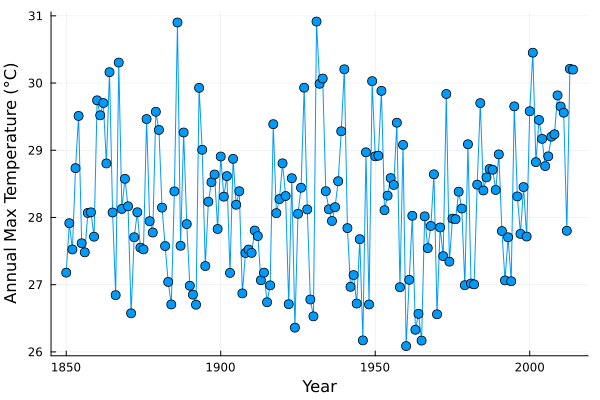

In [4]:
# group data by year and compute the annual maxima
ithaca_dat = dropmissing(ithaca_dat) # drop missing data
maxs = zeros(165).-100 # arbitrarily high number to be replaced
yr = zeros(165)
idx = 1
for i = 2:length(ithaca_dat.Day)
    thisdate = ithaca_dat.Day[i]
    thisyear, thismonth, thisday = yearmonthday(thisdate)
    lastdate = ithaca_dat.Day[i-1]
    lastyear, lastmonth, lastday = yearmonthday(lastdate)
    if (ithaca_dat.TempMax[i] > maxs[idx]) & (thisyear == lastyear)
        maxs[idx] = ithaca_dat.TempMax[i]
        yr[idx] = thisyear
    end
    if thisyear != lastyear
        idx += 1
        maxs[idx] = ithaca_dat.TempMax[i]
        yr[idx] = thisyear
    end
end

# make plot
p1 = plot(
    yr,
    maxs;
    xlabel="Year",
    ylabel="Annual Max Temperature (°C)",
    label=false,
    marker=:circle,
    markersize=5
)

plot(p1)

θ_mle = [27.828895474545362, 1.0168352688316655, -0.21878753180933974]


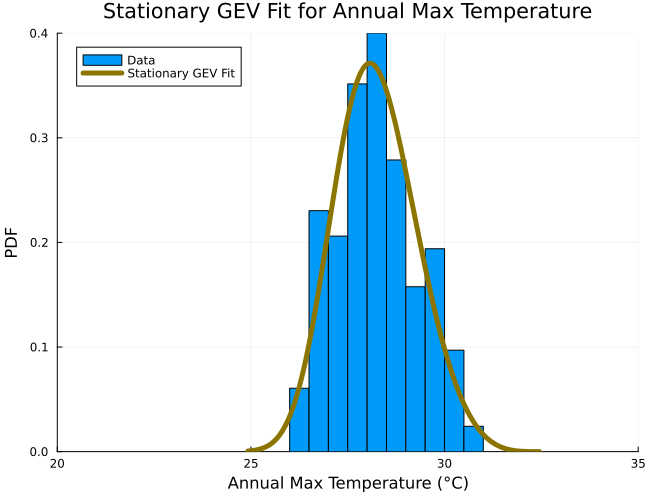

In [45]:
# find Stationary GEV fit
init_θ = [28, 1, 0.0]
lower_bounds = [0.0, 0.0, -10]
upper_bounds = [50, 100.0, 10]
gev_lik(θ) = -sum(logpdf(GeneralizedExtremeValue(θ[1], θ[2], θ[3]), maxs))
θ_mle = Optim.optimize(gev_lik, lower_bounds, upper_bounds, init_θ).minimizer
@show θ_mle

p = histogram(
    maxs,
    normalize=:pdf,
    label="Data",
    xlabel="Annual Max Temperature (°C)",
    ylabel="PDF",
)
plot(p)
plot!(GeneralizedExtremeValue(θ_mle[1], θ_mle[2], θ_mle[3]), linewidth=5, label="Stationary GEV Fit", color=:gold4)
title!("Stationary GEV Fit for Annual Max Temperature")
xlims!((20, 35))
plot!(size=(650, 500))


The GEV is a Weibull distribution due to ξ < 0

In [46]:
# find 100-year return level
rl_100 = quantile(GeneralizedExtremeValue(θ_mle[1], θ_mle[2], θ_mle[3]), 0.99)
@show rl_100 

rl_100 = 30.777735594156532


30.777735594156532

In [7]:
# find Nonstationary GEV fit
init_θ = [5, 1.0, 1.0, 0.0]
lower_bounds = [0.0, 0.0, 0.0, -10]
upper_bounds = [50, 50, 100.0, 10]
gev_lik(θ) = -sum(logpdf.(GeneralizedExtremeValue.(θ[1].+θ[2].*maxs, θ[3], θ[4]), maxs))
θ_mle = Optim.optimize(gev_lik, lower_bounds, upper_bounds, init_θ).minimizer
@show θ_mle

θ_mle = [4.907845237112882, 0.83118876336669, 1.0323712501181477, -3.317899414742615]


4-element Vector{Float64}:
  4.907845237112882
  0.83118876336669
  1.0323712501181477
 -3.317899414742615

In [8]:
stat_aic = -2*(sum(logpdf(GeneralizedExtremeValue(θ_mle[1], θ_mle[2], θ_mle[3]), maxs)) - 3)
nonstat_aic = -2*(sum(logpdf.(GeneralizedExtremeValue.(θ_mle[1].+θ_mle[2].*maxs, θ_mle[3], θ_mle[4]), maxs)) - 4)

@show stat_aic
@show nonstat_aic

stat_aic = 2165.703014328406
nonstat_aic = 427.69035645539964


427.69035645539964

Because this the nonstationary model has a lower AIC value, there is stronger evidence that the data is nonstationary rather than stationary.


### Problem 2

Now let’s analyze how often of the Ithaca temperature data.

**In this problem**:

-   Suppose that we were interested in looking at temperature
    exceedances over 28°C. Decluster these occurrences and plot the
    number of exceedances by year. Have they increased over time?
-   Fit a stationary Poisson-GPD model for the exceedances. What does
    the GPD distribution look like?
-   From your model, estimate the 100-year return level. How does it
    differ from the 100-year return period from the stationary model in
    Problem 1? Why do you think it agrees or disagrees?


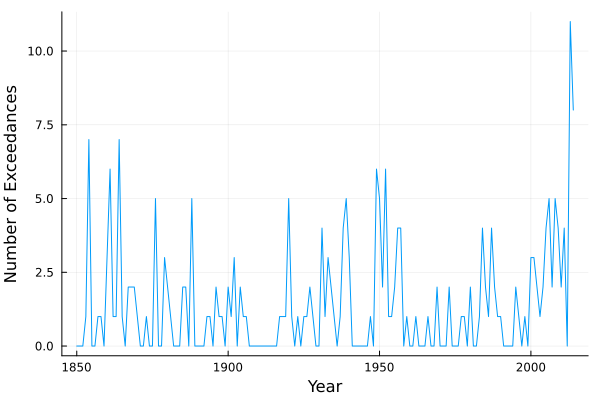

In [22]:
# group data by year and compute the annual maxima
over28 = []
date = []
count = zeros(165)
curr = 0
whichyr = 1
for i = 2:length(ithaca_dat.Day) # we know the first day is not over 28 dw
    thisdate = ithaca_dat.Day[i]
    thisyear, thismonth, thisday = yearmonthday(thisdate)
    lastdate = ithaca_dat.Day[i-1]
    lastyear, lastmonth, lastday = yearmonthday(lastdate)
    if thisyear != lastyear
        curr = 0
        whichyr += 1
    end
    if ithaca_dat.TempMax[i] > 28
        curr += 1
        push!(over28, ithaca_dat.TempMax[i])
        push!(date, ithaca_dat.Day[i])
        count[whichyr] = curr
    end
end

# make plot
p1 = plot(
    yr,
    count;
    xlabel="Year",
    ylabel="Number of Exceedances",
    label=false
)

plot(p1)

The exceedences have not increased by year in general, except for closer to the end of the series.

In [28]:
# find total number of exceedances and exceedance times
S = findall(ithaca_dat.TempMax .> 28)
N = length(S)
T = diff(S) # get difference between adjacent exceedances
θ = 2 * sum(T)^2 / ((N-1) * sum(T.^2)) # extremal index

0.47832378879687915

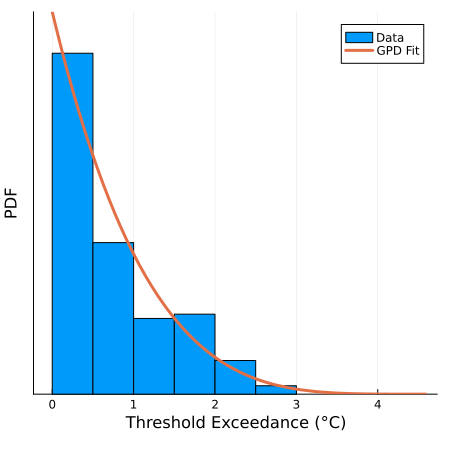

In [61]:
# cluster data points which occur within period
function assign_cluster(dat, period)
    cluster_index = 1
    clusters = zeros(Int, length(dat))
    for i in 1:length(dat)
        if clusters[i] == 0
            clusters[findall(abs.(dat .- dat[i]) .<= period)] .= cluster_index
            cluster_index += 1
        end
    end
    return clusters
end

# cluster exceedances that occur within a four-hour window
# @transform is a macro from DataFramesMeta.jl which adds a new column based on a data transformation
dat_exceed = ithaca_dat[ithaca_dat.TempMax .> 28, :]
dat_exceed = @transform dat_exceed :cluster = assign_cluster(:Day, Dates.Day(round(1/θ)))
# find maximum value within cluster
dat_decluster = combine(dat_exceed -> dat_exceed[argmax(dat_exceed.TempMax), :], 
    groupby(dat_exceed, :cluster))

dat_decluster
p = histogram(dat_decluster.TempMax .- 28,
    normalize = :pdf,
    label="Data",
    xlabel="Threshold Exceedance (°C)",
    ylabel="PDF",
    yticks=[]
    )

# fit GPD
init_θ = [1.0, 1.0]
low_bds = [0.0, -Inf]
up_bds = [Inf, Inf]
gpd_lik(θ) = -sum(logpdf(GeneralizedPareto(0.0, θ[1], θ[2]), dat_decluster.TempMax .- 28))
θ_mle = Optim.optimize(gpd_lik, low_bds, up_bds, init_θ).minimizer
p1 = plot!(p, GeneralizedPareto(0.0, θ_mle[1], θ_mle[2]), linewidth=3, label="GPD Fit")
plot!(size=(450, 450))

The distribution (above) is typical for GPD based on what we have seen in class.

In [62]:
# add column with years of occurrence
dat_decluster = @transform dat_decluster :year = Dates.year.(dat_decluster.Day)
# group by year and add up occurrences
exceed_counts = combine(groupby(dat_decluster, :year), nrow => :count)
delete!(exceed_counts, nrow(exceed_counts)) # including 2023 will bias the count estimate

count_dist = fit(Poisson, exceed_counts.count)
λ = params(count_dist)[1]
σ = θ_mle[1]
ξ = θ_mle[2]

# find 100-year return level
rl_100 = 28 + (σ/ξ)*((100*λ)^ξ-1)
@show rl_100

rl_100 = 30.91645881217761


30.91645881217761

The solution in Problem 1 yielded a return level of 30.78 and for Problem 2 we found 30.92. They agree in general. This is likely because they measure the same underlying process. As such, the phenomena that yielded peaks over 28 degrees also produced maximum peaks.


### Problem 3

**This problem is only required for students in BEE 5850**.

Let’s examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html))contains
data on the relationship between environmental conditions (temperature
and air quality) and deaths in Chicago from 1987–2000. The variables
are:

-   the total number of (non-accidental) deaths each day (`death`);
-   the median density over the city of large pollutant particles (PM10;
    `pm10median`);
-   the median density of smaller pollutant particles (PM2.5;
    `pm25median`);
-   the median concentration of ozone (O$_3$) in the air (`o3median`);
    the median concentration of sulfur dioxide (SO$_2$) in the air
    (`so2median`);
-   the time in days (`time`); and the daily mean temperature (`tmpd`).

The pollution variables have been standardized to represent deviations
from the overall median and the temperature is in Fahrenheit. The days
are given as a number of days relative to December 31, 1993. Note that
some values are missing; these can be treated as missing at random and
dropped in your regressions.

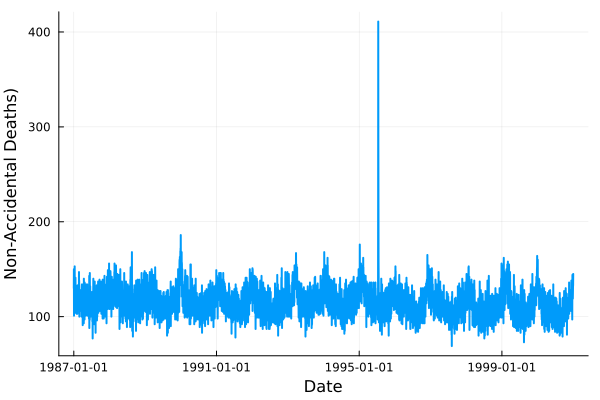

In [123]:
chicago_dat = CSV.read("data/chicago.csv", DataFrame; delim=',', header=true, missingstring="NA")
day_zero = Date("1993-12-31")
chicago_dat.Date = day_zero .+ Day.(chicago_dat.time .+ 0.5)

plot(chicago_dat.Date, chicago_dat.death, lw=2, xlabel="Date", ylabel="Non-Accidental Deaths)", legend=false)

**In this problem**:

-   Load and plot the deaths data. Linearly regress the number of deaths
    against time and report the coefficients for the fitted model. Add
    the regression line to your plot. What does this regression tell
    you?
-   Now linearly regress the deaths data against temperature. Once
    again, report the coefficients, and add the regression line to your
    plot. What does this regression tell you about the influence of
    temperature?
-   Expand your previous model by regressing deaths against temperature
    and PM2.5 density. Report the coefficients and add this regression
    line to your plot.
-   Compute the AICs for the three fitted model and compare them. What
    do they tell you about the relative evidence for the influence of
    temperature and PM2.5 density on deaths? How do your conclusions
    based on AIC compare to those you might draw from your regression
    coefficients and plots?

(μ1_time, μ2_time, σ_time) = (101.40300334169696, 0.00399752405207387, 14.035374300119079)


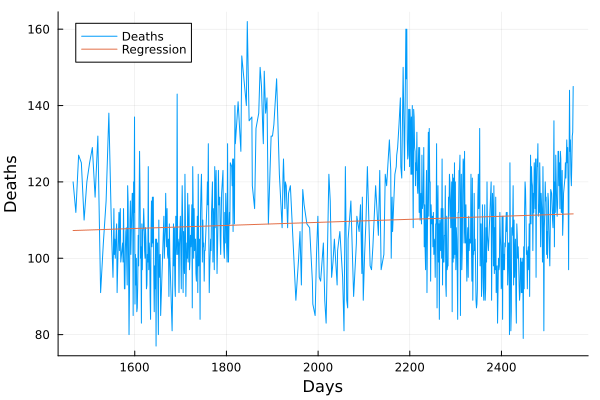

In [125]:
chicago_dat = dropmissing(chicago_dat)

function lin_time(θ, deaths,time) 
    μ1, μ2, σ = θ
    μ = μ1 .+ μ2.*time
    ll = sum(logpdf.(Normal.(μ,σ), deaths))
    return ll
end

lb = [-10.0,-10.0,0.0]
ub = [200.0,200.0,200.0]
p0 = [100.0,100.0,100.0]

θ_mle_time = optimize(θ -> -lin_time(θ, chicago_dat.death, chicago_dat.time), lb, ub, p0).minimizer

μ1_time, μ2_time, σ_time = θ_mle_time
@show μ1_time, μ2_time, σ_time

plot(chicago_dat.time, chicago_dat.death, label = "Deaths")
xlabel!("Days")
ylabel!("Deaths")
plot!(chicago_dat.time, θ_mle_time[1] .+ θ_mle_time[2]*chicago_dat.time, label = "Regression")

This first regression tells us that there is a general downward slope over time. However, the regression doesn't even attempt to capture any of the structure of the data (e.g., periodicity)

(μ1_temp, μ2_temp, σ_temp) = (128.92525295955247, -0.36188856607187553, 12.392039985696561)


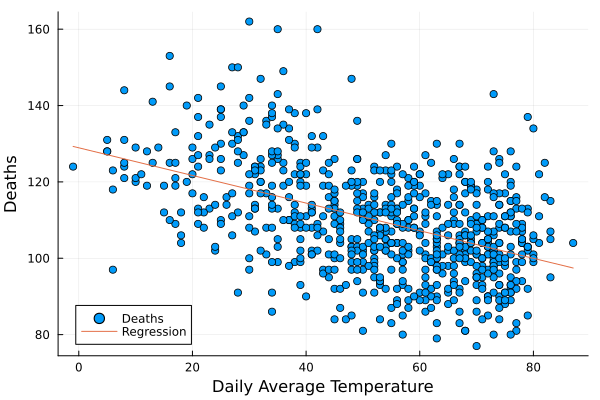

In [126]:
function lin_temp(θ, deaths,tmpd) 
    μ1, μ2, σ = θ
    μ = μ1 .+ μ2.*tmpd
    ll = sum(logpdf.(Normal.(μ,σ), deaths))
    return ll
end

lb = [-10.0,-10.0,0.0]
ub = [200.0,200.0,200.0]
p0 = [100.0,100.0,100.0]

θ_mle_temp = optimize(θ -> -lin_temp(θ, chicago_dat.death, chicago_dat.tmpd), lb, ub, p0).minimizer
μ1_temp, μ2_temp, σ_temp = θ_mle_temp
@show μ1_temp, μ2_temp, σ_temp

scatter(chicago_dat.tmpd, chicago_dat.death, label = "Deaths")
xlabel!("Daily Average Temperature")
ylabel!("Deaths")
plot!(chicago_dat.tmpd, θ_mle_temp[1] .+ θ_mle_temp[2]*chicago_dat.tmpd, label = "Regression")

This regression indicates that temperature is inversely related to deaths, albeit with a large standard deviation.

In [127]:
function lin_temppm25(θ, deaths, tmpd, pm25) 
    μ1, μ2, μ3, σ = θ
    μ = μ1 .+ μ2.*tmpd .+ μ3.*pm25
    ll = sum(logpdf.(Normal.(μ,σ), deaths))
    return ll
end

lb = [-10.0,-10.0,-10.0,0.0]
ub = [200.0,200.0,200.0,200.0]
p0 = [100.0,100.0,100.0,100.0]

θ_mle_temppm25 = optimize(θ -> -lin_temppm25(θ, chicago_dat.death, chicago_dat.tmpd, chicago_dat.pm25median), lb, ub, p0).minimizer
μ1_temppm25, μ2_temppm25, μ3_temppm25, σ_temppm25 = θ_mle_temppm25
@show μ1_temppm25, μ2_temppm25, μ3_temppm25, σ_temppm25

# scatter(chicago_dat.tmpd, chicago_dat.death, label = "Deaths")
# xlabel!("Daily Average Temperature")
# ylabel!("Deaths")
# plot!(chicago_dat.tmpd, θ_mle_temppm25[1] .+ θ_mle_temppm25[2]*chicago_dat.tmpd .+ θ_mle_temppm25[3]*chicago_dat.pm25median, label = "Regression")

(μ1_temppm25, μ2_temppm25, μ3_temppm25, σ_temppm25) = (129.0133521752948, -0.36459227154955753, 0.21436220966678315, 12.251005380767939)


(129.0133521752948, -0.36459227154955753, 0.21436220966678315, 12.251005380767939)

In [130]:
aic_time = -2*(lin_time(θ_mle_time, chicago_dat.death, chicago_dat.time)-3)
aic_temp = -2*(lin_temp(θ_mle_temp, chicago_dat.death, chicago_dat.tmpd)-3)
aic_temppm25 = -2*(lin_temppm25(θ_mle_temppm25, chicago_dat.death, chicago_dat.tmpd, chicago_dat.pm25median)-4)

@show aic_time
@show aic_temp
@show aic_temppm25

aic_time = 5845.026913996759
aic_temp = 5665.9577370634215
aic_temppm25 = 5651.497922638995


5651.497922638995

The results indicate that addting temperature positively increases the model performance. Adding PM 2.5 gave a lesser (magnitude of) change in AIC value but was still beneficial, particularly taking into consideration that there were more parameters. This is the same result that would be expected from the graphs, especially considering how well the regression already appeared to fit the Deaths vs. Temperature plot. It is unsurprising that adding PM 2.5 was valueable but less so than switching "time" for "temperature". This is also evident in the σ values of the models, which decrease as the models increase in "skill".